# EDA de GitHub Agentic Workflows

Este notebook explora el dataset propio de chikiMiner, publicado en https://huggingface.co/datasets/SebaS01010101/GHAW-H. Se ejecuta desde un kernel limpio: importa sus dependencias, carga los cuatro Parquet y reconstruye todas las variables derivadas en memoria. No usa el dataset temporal de pavtch/GHAW-H.

# 1. Carga de los datos para el análisis

## 1.1 Fuente y rutas

Se utiliza exclusivamente el dataset propio de huggingface-dataset/, publicado en https://huggingface.co/datasets/SebaS01010101/GHAW-H. La variable CHIKIMINER_EDA_DATA_DIR permite indicar otra ubicación; si no existe, se busca el directorio local en la ubicación de ejecución y sus padres.

## 1.2 Tablas derivadas en memoria

- body_features: una fila por file_id, con longitud y bandera de body vacío.
- frontmatter_file_summary: una fila por file_id, agregada antes de cualquier join analítico.
- file_features: una fila por archivo, sin multiplicación por nodos YAML.
- repository_features: una fila por repositorio, incluyendo los cinco repositorios sin archivos.

In [1]:
from pathlib import Path
import json
import os
import re

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='notebook')
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass
TABLE_FILES = {
    'repositories': 'repositories.parquet',
    'workflow_files': 'workflow_files.parquet',
    'frontmatter_fields': 'frontmatter_fields.parquet',
    'workflow_bodies': 'workflow_bodies.parquet',
}

def find_dataset_dir():
    candidates = []
    configured = os.environ.get('CHIKIMINER_EDA_DATA_DIR')
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd()
    candidates.extend([current / 'huggingface-dataset', current.parent / 'huggingface-dataset'])
    candidates.extend(parent / 'huggingface-dataset' for parent in current.parents)
    for candidate in candidates:
        candidate = candidate.resolve()
        if all((candidate / filename).is_file() for filename in TABLE_FILES.values()):
            return candidate
    raise FileNotFoundError('No se encontraron los cuatro Parquet requeridos.')

DATA_DIR = find_dataset_dir()
PARQUET_PATHS = {name: DATA_DIR / filename for name, filename in TABLE_FILES.items()}
missing = [str(path) for path in PARQUET_PATHS.values() if not path.is_file()]
assert not missing, f'Faltan archivos Parquet: {missing}'
tables = {name: pd.read_parquet(path) for name, path in PARQUET_PATHS.items()}
repositories = tables['repositories']
workflow_files = tables['workflow_files']
frontmatter_fields = tables['frontmatter_fields']
workflow_bodies = tables['workflow_bodies']
display(Markdown('**Directorio de datos:** ' + str(DATA_DIR) + '\n\n**Hugging Face:** https://huggingface.co/datasets/SebaS01010101/GHAW-H\n\nNo se utiliza el dataset temporal de pavtch/GHAW-H.'))


**Directorio de datos:** C:\Users\vicen\OneDrive\Documentos\GitHub\Ing de Datos\ChikiMiner\huggingface-dataset

**Hugging Face:** https://huggingface.co/datasets/SebaS01010101/GHAW-H

No se utiliza el dataset temporal de pavtch/GHAW-H.

In [2]:
def first_unescaped_dot(path):
    escaped = False
    for index, character in enumerate(str(path)):
        if character == chr(92) and not escaped:
            escaped = True
            continue
        if character == '.' and not escaped:
            return index
        escaped = False
    return -1

def root_key(path):
    path = str(path)
    separator = first_unescaped_dot(path)
    return path if separator == -1 else path[:separator]

assert root_key('permissions.contents') == 'permissions'
assert root_key('tools.github.toolsets') == 'tools'
assert root_key('ms' + chr(92) + '.date') == 'ms' + chr(92) + '.date'
assert root_key('metadata.date') == 'metadata'

body_series = workflow_bodies['body_markdown'].fillna('').astype('string')
body_features = pd.DataFrame({
    'file_id': workflow_bodies['file_id'],
    'body_chars': body_series.str.len().fillna(0).astype('int64'),
    'body_words': body_series.str.strip().str.split().str.len().fillna(0).astype('int64'),
})
body_features['is_empty_body'] = body_series.map(lambda value: bool(re.fullmatch(r'\s*', str(value))))

field_profile = frontmatter_fields.copy()
field_profile['root_key'] = field_profile['key_path'].map(root_key)
field_profile['depth'] = field_profile['key_path'].map(lambda value: sum(1 for i, char in enumerate(str(value)) if char == '.' and (i == 0 or str(value)[i - 1] != chr(92))) + 1)

def decode_json(raw):
    try:
        return json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        return None

field_profile['decoded_value'] = field_profile['value_json'].map(decode_json)
field_counts = field_profile.groupby('file_id').size().rename('n_frontmatter_fields')
frontmatter_file_summary = workflow_files[['file_id']].drop_duplicates().merge(field_counts, on='file_id', how='left', validate='one_to_one')
frontmatter_file_summary['n_frontmatter_fields'] = frontmatter_file_summary['n_frontmatter_fields'].fillna(0).astype('int64')
frontmatter_file_summary['has_frontmatter'] = frontmatter_file_summary['n_frontmatter_fields'].gt(0)

file_features = workflow_files[['file_id', 'repository_id', 'filename', 'path']].merge(body_features, on='file_id', how='left', validate='one_to_one').merge(frontmatter_file_summary, on='file_id', how='left', validate='one_to_one')
assert len(file_features) == workflow_files['file_id'].nunique()

repository_features = repositories[['repository_id', 'full_name', 'owner']].copy()
repo_counts = workflow_files.groupby('repository_id').size().rename('n_files')
repository_features = repository_features.merge(repo_counts, on='repository_id', how='left', validate='one_to_one')
repository_features['n_files'] = repository_features['n_files'].fillna(0).astype('int64')
repo_body_medians = file_features.groupby('repository_id')['body_words'].median().rename('median_body_words')
repo_field_medians = file_features.groupby('repository_id')['n_frontmatter_fields'].median().rename('median_frontmatter_fields')
repository_features = repository_features.merge(repo_body_medians, on='repository_id', how='left', validate='one_to_one').merge(repo_field_medians, on='repository_id', how='left', validate='one_to_one')
assert len(repository_features) == repositories['repository_id'].nunique()

display(pd.DataFrame({
    'derived_table': ['body_features', 'frontmatter_file_summary', 'file_features', 'repository_features'],
    'rows': [len(body_features), len(frontmatter_file_summary), len(file_features), len(repository_features)],
    'row_unit': ['file_id', 'file_id', 'archivo Markdown', 'repository_id'],
}))

,derived_table,rows,row_unit
0,body_features,1541,file_id
1,frontmatter_file_summary,1541,file_id
2,file_features,1541,archivo Markdown
3,repository_features,374,repository_id


# 2. Distribución de archivos por repositorio

La unidad es el repositorio. Se parte de repositories y se hace un left join con los conteos de archivos, de forma que los cinco repositorios sin archivos quedan representados con n_files = 0. Las estadísticas y el histograma se calculan con los 374 repositorios, sin hardcodear los nombres ni las cifras.

,metric,value
0,repositories,374.00
1,repositories_with_files,369.00
2,repositories_with_zero_files,5.00
3,minimum_files,0.00
4,maximum_files,299.00
5,mean_files,4.12
6,median_files,2.00


**Repositorios con más archivos**

,full_name,n_files
159,github/gh-aw,299
161,github/gh-aw-firewall,71
114,elastic/ai-github-actions,58
252,microsoft/testfx,37
162,github/gh-aw-mcpg,36
165,githubnext/ado-aw,26
168,githubnext/gh-aw-workshop,23
318,rysweet/amplihack,20
260,microsoft/vstest,15
312,pydantic/pydantic-ai,15


**Repositorios con cero archivos**

,full_name,n_files
48,BMayhew/awesome-sites-to-test-on,0
273,neurodesk/neurodesktop,0
293,pikax/verter,0
333,SocketDev/action,0
341,stride3d/stride-community-toolkit,0


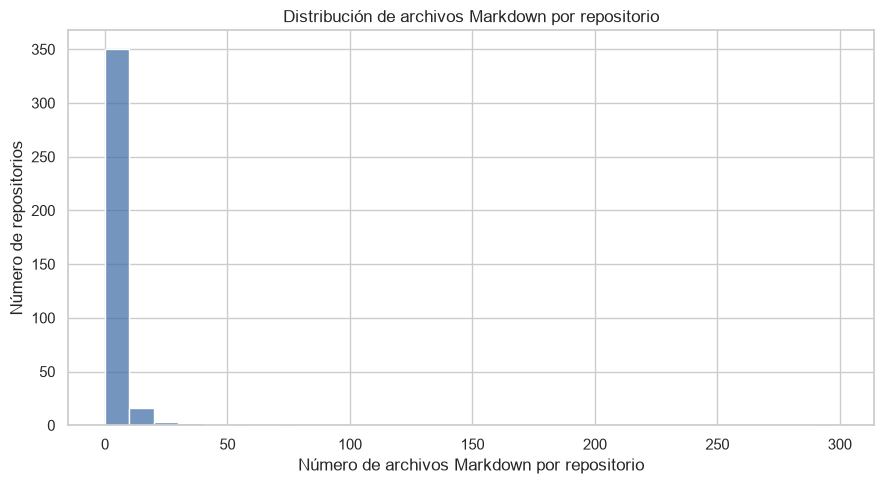

In [3]:
repo_distribution_stats = pd.DataFrame([{
    'metric': metric,
    'value': value,
} for metric, value in {
    'repositories': len(repository_features),
    'repositories_with_files': int(repository_features['n_files'].gt(0).sum()),
    'repositories_with_zero_files': int(repository_features['n_files'].eq(0).sum()),
    'minimum_files': int(repository_features['n_files'].min()),
    'maximum_files': int(repository_features['n_files'].max()),
    'mean_files': round(repository_features['n_files'].mean(), 2),
    'median_files': round(repository_features['n_files'].median(), 2),
}.items()])
display(repo_distribution_stats)
display(Markdown('**Repositorios con más archivos**'))
display(repository_features.nlargest(15, 'n_files')[['full_name', 'n_files']])
display(Markdown('**Repositorios con cero archivos**'))
display(repository_features.loc[repository_features['n_files'].eq(0), ['full_name', 'n_files']])

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=repository_features, x='n_files', bins=30, discrete=False, color='#4472A8', ax=ax)
ax.set_title('Distribución de archivos Markdown por repositorio')
ax.set_xlabel('Número de archivos Markdown por repositorio')
ax.set_ylabel('Número de repositorios')
fig.tight_layout()
plt.show()

# 3. Exploración del frontmatter

La cobertura se calcula a nivel archivo mediante nunique(file_id). El denominador es el número de archivos Markdown, no el número de filas de frontmatter_fields. Los tres atributos seleccionados son engine, timeout-minutes y los triggers derivados de los paths hijos de on.*.

In [4]:
n_files_total = workflow_files['file_id'].nunique()
field_coverage = field_profile.groupby('root_key')['file_id'].nunique().rename('files_with_field').reset_index()
field_coverage['percentage_files'] = (100 * field_coverage['files_with_field'] / n_files_total).round(2)
field_coverage = field_coverage.rename(columns={'root_key': 'field'}).sort_values(['files_with_field', 'field'], ascending=[False, True])
display(field_coverage)
display(Markdown('El porcentaje usa ' + str(n_files_total) + ' archivos Markdown como denominador. Una fila de frontmatter_fields no se cuenta como un archivo adicional.'))

,field,files_with_field,percentage_files
41,on,1492,96.82
42,permissions,1486,96.43
54,safe-outputs,1418,92.02
65,tools,1379,89.49
5,description,1339,86.89
...,...,...,...
33,metadata,1,0.06
36,ms\.date,1,0.06
37,ms\.topic,1,0.06
47,redirect,1,0.06


El porcentaje usa 1541 archivos Markdown como denominador. Una fila de frontmatter_fields no se cuenta como un archivo adicional.

**Atributo 1: engine normalizado a una categoría principal por archivo cuando es posible.**

,engine,n_files,percentage
4,copilot,592,38.42
1,claude,154,9.99
3,codex,122,7.92
13,pi,11,0.71
8,gemini,4,0.26
12,opencode,4,0.26
0,aider,3,0.19
9,goose,3,0.19
14,pydantic-ai,2,0.13
2,claude-sonnet-5,1,0.06


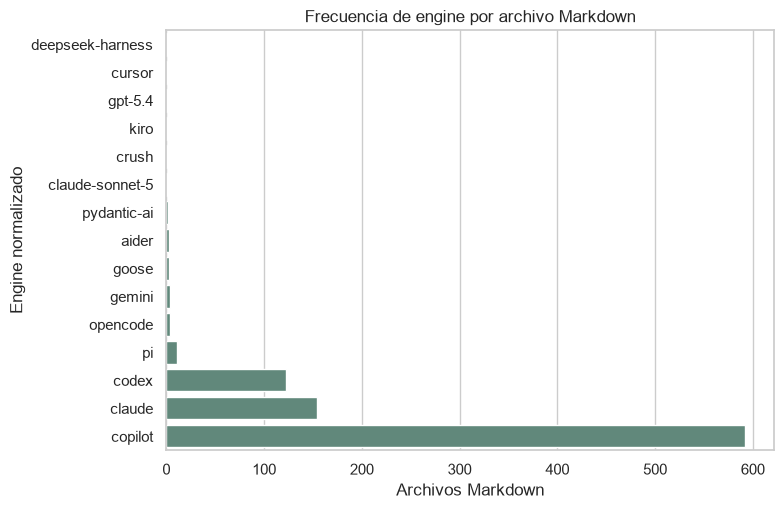

Interpretación: las frecuencias describen la composición observada del snapshot. No permiten concluir que un engine cause una estructura concreta del workflow.

In [5]:
def engine_label(value):
    if isinstance(value, str):
        return value.strip() or None
    if isinstance(value, dict):
        for key in ('id', 'name', 'engine', 'model'):
            candidate = value.get(key)
            if isinstance(candidate, str) and candidate.strip():
                return candidate.strip()
        return '(mapping sin identificador)'
    return None

engine_rows = field_profile.loc[field_profile['root_key'].eq('engine')].copy()
engine_priority = {'engine.id': 0, 'engine.name': 1, 'engine.model': 2, 'engine': 3}
engine_rows['priority'] = engine_rows['key_path'].map(lambda value: engine_priority.get(value, 10))
engine_rows['engine'] = engine_rows['decoded_value'].map(engine_label)
engine_per_file = engine_rows.dropna(subset=['engine']).sort_values(['file_id', 'priority']).drop_duplicates('file_id')[['file_id', 'engine']]
engine_per_file['engine'] = engine_per_file['engine'].map(lambda value: value.strip().casefold())
file_features = file_features.drop(columns=['engine'], errors='ignore').merge(engine_per_file, on='file_id', how='left', validate='one_to_one')
engine_summary = engine_per_file.groupby('engine')['file_id'].nunique().rename('n_files').reset_index().sort_values('n_files', ascending=False)
engine_summary['percentage'] = (100 * engine_summary['n_files'] / n_files_total).round(2)
display(Markdown('**Atributo 1: engine normalizado a una categoría principal por archivo cuando es posible.**'))
display(engine_summary)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(engine_summary))))
engine_plot = engine_summary.sort_values('n_files')
sns.barplot(data=engine_plot, x='n_files', y='engine', color='#5B8E7D', ax=ax)
ax.set_title('Frecuencia de engine por archivo Markdown')
ax.set_xlabel('Archivos Markdown')
ax.set_ylabel('Engine normalizado')
fig.tight_layout()
plt.show()
display(Markdown('Interpretación: las frecuencias describen la composición observada del snapshot. No permiten concluir que un engine cause una estructura concreta del workflow.'))

**Atributo 2: timeout-minutes.** Se usa el path exacto; timeout_minutes no se mezcla. Los valores no enteros no se fuerzan a número.

,metric,value
0,numeric_values,1088.00
1,non_numeric_values,1.00
2,minimum,5.00
3,maximum,350.00
4,mean,33.33
5,median,30.00


**Valores no numéricos**

,file_id,key_path,value_type,value_json,decoded_value
9712,2b163a46147f5327e6f0979427726dca2736633d37c40e...,timeout-minutes,string,"""${{ inputs.worker_timeout_minutes || 20 }}""",${{ inputs.worker_timeout_minutes || 20 }}


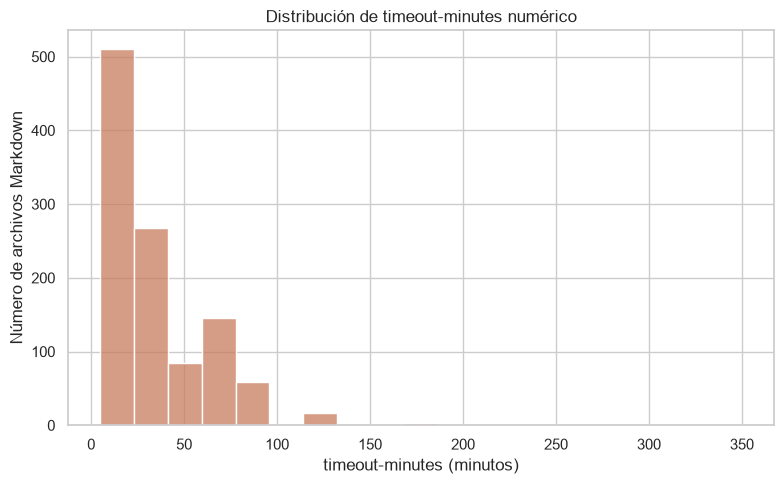

In [6]:
def scalar_value(value):
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        return value
    return None

timeout_rows = field_profile.loc[field_profile['key_path'].eq('timeout-minutes')].copy()
timeout_rows['decoded_scalar'] = timeout_rows['decoded_value'].map(scalar_value)
timeout_per_file = timeout_rows.sort_values('file_id').drop_duplicates('file_id')
timeout_numeric = timeout_per_file.loc[timeout_per_file['value_type'].eq('integer') & timeout_per_file['decoded_scalar'].notna(), 'decoded_scalar']
timeout_non_numeric = timeout_per_file.loc[~(timeout_per_file['value_type'].eq('integer') & timeout_per_file['decoded_scalar'].notna()), ['file_id', 'key_path', 'value_type', 'value_json', 'decoded_value']]
timeout_stats = pd.DataFrame([{
    'metric': metric,
    'value': value,
} for metric, value in {
    'numeric_values': len(timeout_numeric),
    'non_numeric_values': len(timeout_non_numeric),
    'minimum': timeout_numeric.min() if len(timeout_numeric) else None,
    'maximum': timeout_numeric.max() if len(timeout_numeric) else None,
    'mean': round(timeout_numeric.mean(), 2) if len(timeout_numeric) else None,
    'median': timeout_numeric.median() if len(timeout_numeric) else None,
}.items()])
display(Markdown('**Atributo 2: timeout-minutes.** Se usa el path exacto; timeout_minutes no se mezcla. Los valores no enteros no se fuerzan a número.'))
display(timeout_stats)
display(Markdown('**Valores no numéricos**'))
display(timeout_non_numeric)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(timeout_numeric, bins=min(20, max(5, timeout_numeric.nunique())), color='#C97C5D', ax=ax)
ax.set_title('Distribución de timeout-minutes numérico')
ax.set_xlabel('timeout-minutes (minutos)')
ax.set_ylabel('Número de archivos Markdown')
fig.tight_layout()
plt.show()

**Atributo 3: triggers derivados de paths hijos de on.** No se usa el JSON completo de on como una sola categoría.

,trigger,n_files,percentage
38,workflow_dispatch,1054,68.40
25,schedule,772,50.10
24,roles,252,16.35
20,reaction,190,12.33
32,slash_command,188,12.20
9,issues,169,10.97
15,pull_request,153,9.93
14,permissions,120,7.79
35,steps,112,7.27
37,workflow_call,95,6.16


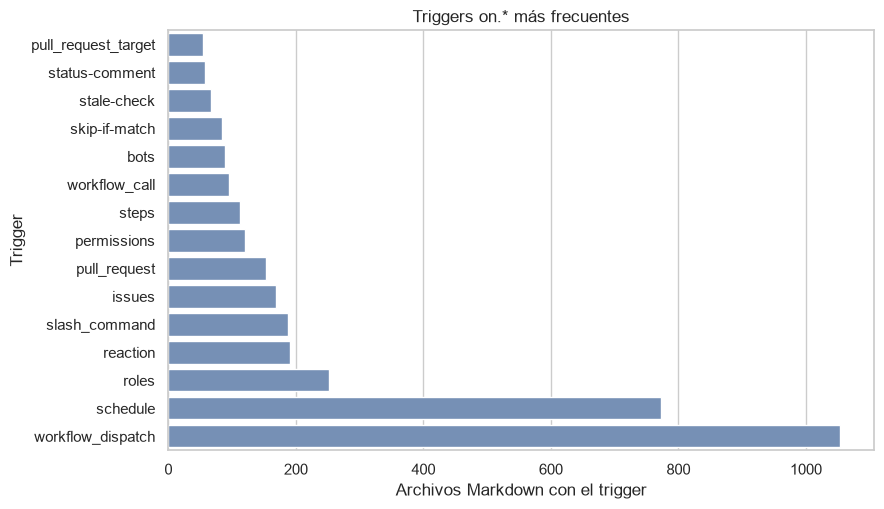

Un archivo puede tener varios triggers. Por eso la suma de porcentajes puede superar 100%; cada porcentaje usa archivos distintos como unidad, pero no son categorías mutuamente excluyentes.

In [7]:
def child_after_root(path):
    separator = first_unescaped_dot(path)
    if separator == -1:
        return None
    remainder = str(path)[separator + 1:]
    next_separator = first_unescaped_dot(remainder)
    return remainder if next_separator == -1 else remainder[:next_separator]

trigger_rows = field_profile.loc[field_profile['root_key'].eq('on')].copy()
trigger_rows['trigger'] = trigger_rows['key_path'].map(child_after_root)
trigger_rows = trigger_rows.dropna(subset=['trigger'])
trigger_summary = trigger_rows.groupby('trigger')['file_id'].nunique().rename('n_files').reset_index().sort_values('n_files', ascending=False)
trigger_summary['percentage'] = (100 * trigger_summary['n_files'] / n_files_total).round(2)
display(Markdown('**Atributo 3: triggers derivados de paths hijos de on.** No se usa el JSON completo de on como una sola categoría.'))
display(trigger_summary)

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * min(15, len(trigger_summary)))))
trigger_plot = trigger_summary.head(15).sort_values('n_files')
sns.barplot(data=trigger_plot, x='n_files', y='trigger', color='#6C8EBF', ax=ax)
ax.set_title('Triggers on.* más frecuentes')
ax.set_xlabel('Archivos Markdown con el trigger')
ax.set_ylabel('Trigger')
fig.tight_layout()
plt.show()
display(Markdown('Un archivo puede tener varios triggers. Por eso la suma de porcentajes puede superar 100%; cada porcentaje usa archivos distintos como unidad, pero no son categorías mutuamente excluyentes.'))

# 4. Exploración del body

La unidad es el archivo Markdown. La longitud se define como body.strip().split(): un body nulo, vacío o compuesto solo por whitespace produce cero palabras. Los outliers se conservan para el cálculo y solo se puede limitar la ventana visual.

,metric,value
0,files,1541.00
1,empty_bodies,1.00
2,minimum_words,0.00
3,maximum_words,15217.00
4,mean_words,1063.67
5,median_words,750.00
6,p25_words,352.00
7,p75_words,1365.00


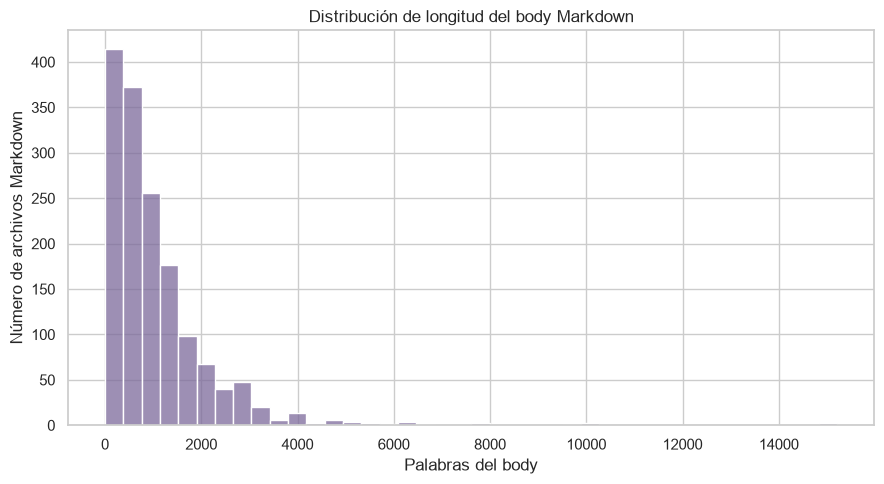

La figura conserva todos los valores. El percentil 99 dinámico es 5365.6 palabras y sirve únicamente como referencia visual.

**Ejemplos de bodies más extensos**

,full_name,path,body_words
917,dotnet/maui,.github/workflows/ci-status-fix-net11.md,15217
620,dotnet/maui,.github/workflows/ci-status-fix.md,15175
524,Azure/terraform-azurerm-avm-res-resources-reso...,.github/workflows/issue-triage.md,10191
954,dotnet/aspnetcore,.github/workflows/test-quarantine.md,10170
772,tenstorrent/tt-metal,.github/workflows/silencer.md,9549
814,dotnet/fsharp,.github/workflows/agentic-state-machine.md,7949
208,openvinotoolkit/openvino,.github/workflows/ci-doctor-mq.md,7637
1485,ishandutta2007/openvino,.github/workflows/ci-doctor-mq.md,7637
1523,github/gh-aw-firewall,.github/workflows/self-hosted-runner-doctor.md,6752
23,dotnet/aspire,.github/workflows/milestone-changelog.md,6274


In [8]:
body_q1, body_q3 = body_features['body_words'].quantile([0.25, 0.75])
body_summary = pd.DataFrame([{
    'metric': metric,
    'value': value,
} for metric, value in {
    'files': len(body_features),
    'empty_bodies': int(body_features['is_empty_body'].sum()),
    'minimum_words': int(body_features['body_words'].min()),
    'maximum_words': int(body_features['body_words'].max()),
    'mean_words': round(body_features['body_words'].mean(), 2),
    'median_words': round(body_features['body_words'].median(), 2),
    'p25_words': round(body_q1, 2),
    'p75_words': round(body_q3, 2),
}.items()])
display(body_summary)

body_p99 = body_features['body_words'].quantile(0.99)
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=body_features, x='body_words', bins=40, color='#7C6A9B', ax=ax)
ax.set_title('Distribución de longitud del body Markdown')
ax.set_xlabel('Palabras del body')
ax.set_ylabel('Número de archivos Markdown')
fig.tight_layout()
plt.show()
display(Markdown('La figura conserva todos los valores. El percentil 99 dinámico es ' + str(round(body_p99, 2)) + ' palabras y sirve únicamente como referencia visual.'))

file_repo_body = workflow_bodies[['file_id']].merge(workflow_files[['file_id', 'repository_id', 'path']], on='file_id', how='left', validate='one_to_one').merge(repositories[['repository_id', 'full_name']], on='repository_id', how='left', validate='many_to_one').merge(body_features, on='file_id', how='left', validate='one_to_one')
extreme_examples = file_repo_body.nlargest(10, 'body_words')[['full_name', 'path', 'body_words']]
display(Markdown('**Ejemplos de bodies más extensos**'))
display(extreme_examples)

# 5. Relaciones entre variables

Las dos preguntas son descriptivas y usan unidades explícitas. Los joins se validan y los campos YAML se agregan a nivel file_id antes de unirlos a bodies o repositorios. No se calcula causalidad.

## 5.1 Pregunta exploratoria 1

**¿La categoría de engine se relaciona con la longitud del body?**

Unidad: archivo Markdown. Se excluyen únicamente los archivos sin engine para este análisis; no se eliminan de file_features. La tabla resume n, media, mediana, P25 y P75. La figura usa las categorías con al menos diez observaciones cuando existen y oculta los puntos extremos solo para mejorar la lectura del boxplot; los datos completos permanecen en la tabla.

,engine,n,mean,median,p25,p75
4,copilot,592,1085.702703,738.0,345.75,1384.50
1,claude,154,1079.246753,791.0,373.75,1461.50
3,codex,122,922.819672,645.5,317.25,1225.75
13,pi,11,1336.727273,1243.0,933.00,1950.00
8,gemini,4,427.500000,470.0,387.25,510.25
12,opencode,4,1024.000000,364.0,270.50,1117.50
0,aider,3,285.333333,318.0,267.00,320.00
9,goose,3,1025.000000,1273.0,780.50,1393.50
14,pydantic-ai,2,284.000000,284.0,256.50,311.50
2,claude-sonnet-5,1,10191.000000,10191.0,10191.00,10191.00


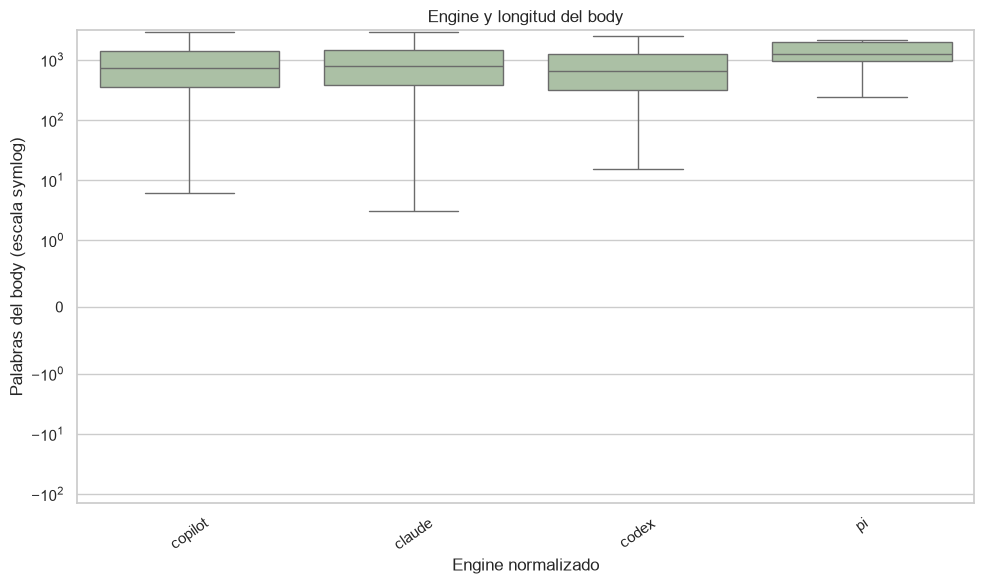

Interpretación: se comparan distribuciones observadas por engine. Una mediana mayor describe este snapshot y no demuestra que el engine produzca bodies más largos.

In [9]:
engine_body = file_features.dropna(subset=['engine'])[['file_id', 'engine', 'body_words']].copy()
q1_summary = engine_body.groupby('engine')['body_words'].agg(n='size', mean='mean', median='median', p25=lambda values: values.quantile(0.25), p75=lambda values: values.quantile(0.75)).reset_index().sort_values('n', ascending=False)
display(q1_summary)
plot_engines = q1_summary.loc[q1_summary['n'].ge(10), 'engine'].head(8).tolist()
if not plot_engines:
    plot_engines = q1_summary['engine'].head(8).tolist()
plot_engine_body = engine_body.loc[engine_body['engine'].isin(plot_engines)]
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=plot_engine_body, x='engine', y='body_words', order=plot_engines, color='#A8C5A0', showfliers=False, ax=ax)
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Engine y longitud del body')
ax.set_xlabel('Engine normalizado')
ax.set_ylabel('Palabras del body (escala symlog)')
ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
plt.show()
display(Markdown('Interpretación: se comparan distribuciones observadas por engine. Una mediana mayor describe este snapshot y no demuestra que el engine produzca bodies más largos.'))

## 5.2 Pregunta exploratoria 2

**¿Los repositorios con más archivos Markdown presentan bodies típicamente más largos?**

Unidad: repositorio. n_files se conserva para los 374 repositorios; los cinco sin body medible quedan fuera únicamente del scatter porque no tienen mediana de palabras. Se mantiene una sola fila por repositorio. Se usa escala logarítmica en X cuando la asimetría del número de archivos lo justifica.

,repository_id,full_name,n_files,median_body_words
159,9269ad244752776eb063942bbc7fe2064fd52c87a0b654...,github/gh-aw,299,938.0
161,d924afba7a8c10a2f7409677bc09bfba53aaaa1da6f801...,github/gh-aw-firewall,71,373.0
114,e268ce83c85b09e0043a02bf2c4d2c559fad67afacf4f6...,elastic/ai-github-actions,58,598.5
252,ba3fa2cef357785ddaaed9e32aa852e93c85bef586c730...,microsoft/testfx,37,531.0
162,97d8910c4c30682ceba4258ad5b2a45941a486405e14ef...,github/gh-aw-mcpg,36,988.5
...,...,...,...,...
48,6559dff0e9ab463f5761c2abdbf7c921f9f91bee050a9b...,BMayhew/awesome-sites-to-test-on,0,NaN
333,711d26e018e99081364d03363944cf806161cd4b87869e...,SocketDev/action,0,NaN
273,70a418ea2f61bdcb3f2a3a4cc4641d4efccafea3a6516d...,neurodesk/neurodesktop,0,NaN
293,9ab29c944a39a32c64878124e14653b23700301abe2d4a...,pikax/verter,0,NaN


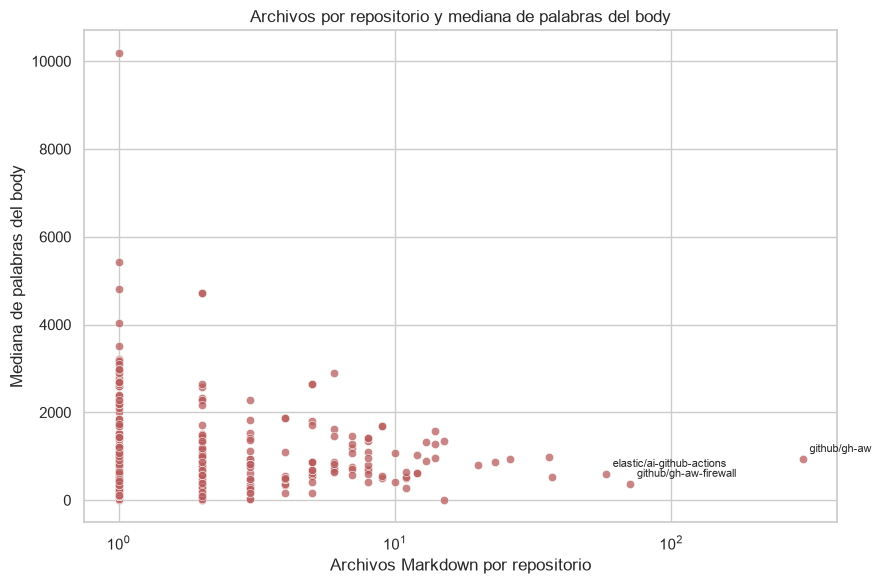

Interpretación: el scatter resume una asociación descriptiva a nivel repositorio. Los repositorios sin body medible se conservan en la tabla y no se imputan para la figura.

In [10]:
q2_table = repository_features[['repository_id', 'full_name', 'n_files', 'median_body_words']].sort_values(['n_files', 'full_name'], ascending=[False, True])
display(q2_table)
scatter_data = q2_table.dropna(subset=['median_body_words']).loc[lambda frame: frame['n_files'].gt(0)].copy()
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=scatter_data, x='n_files', y='median_body_words', color='#B85C5C', alpha=0.75, ax=ax)
if not scatter_data.empty and scatter_data['n_files'].max() / max(scatter_data['n_files'].min(), 1) >= 10:
    ax.set_xscale('log')
for _, row in scatter_data.nlargest(3, 'n_files').iterrows():
    ax.annotate(row['full_name'], (row['n_files'], row['median_body_words']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_title('Archivos por repositorio y mediana de palabras del body')
ax.set_xlabel('Archivos Markdown por repositorio')
ax.set_ylabel('Mediana de palabras del body')
fig.tight_layout()
plt.show()
display(Markdown('Interpretación: el scatter resume una asociación descriptiva a nivel repositorio. Los repositorios sin body medible se conservan en la tabla y no se imputan para la figura.'))

# 6. Hallazgos y limitaciones

Los hallazgos se generan después de ejecutar los cálculos anteriores, de manera que las cifras reflejan el snapshot local y no valores escritos manualmente.

In [11]:
top_repo = repository_features.nlargest(1, 'n_files').iloc[0]
top_engine = engine_summary.iloc[0] if not engine_summary.empty else None
top_trigger = trigger_summary.iloc[0] if not trigger_summary.empty else None
top10_share = 100 * repository_features.nlargest(10, 'n_files')['n_files'].sum() / max(workflow_files['file_id'].nunique(), 1)
zero_repositories = int(repository_features['n_files'].eq(0).sum())
empty_bodies = int(body_features['is_empty_body'].sum())
outlier_count = int((body_features['body_words'] > (body_q3 + 1.5 * (body_q3 - body_q1))).sum())

finding_one = (
    '### Hallazgo 1 — Concentración de archivos\n\n'
    '**Resultado:** el repositorio con más archivos es ' + str(top_repo['full_name']) + ' con ' + str(int(top_repo['n_files'])) + ' archivos; los diez repositorios principales concentran ' + str(round(top10_share, 2)) + '% de los archivos.\n\n'
    '**Evidencia:** tabla de distribución por repositorio y figura de archivos por repositorio.\n\n'
    '**Interpretación:** la distribución tiene una cola alta y no representa una colección uniforme de repositorios.'
)
finding_two = (
    '### Hallazgo 2 — Cobertura heterogénea del frontmatter\n\n'
    '**Resultado:** el engine más frecuente entre los archivos que lo declaran es ' + (str(top_engine['engine']) + ' (' + str(int(top_engine['n_files'])) + ' archivos).' if top_engine is not None else 'no se pudo determinar.') + '\n\n'
    '**Evidencia:** tabla de cobertura de root keys, tabla de engine y tabla de timeout-minutes.\n\n'
    '**Interpretación:** los atributos son opcionales y su presencia varía; ausencia no equivale a un error de calidad.'
)
finding_three = (
    '### Hallazgo 3 — Longitud desigual de los bodies\n\n'
    '**Resultado:** la mediana es ' + str(round(body_features['body_words'].median(), 2)) + ' palabras, el máximo es ' + str(int(body_features['body_words'].max())) + ' y se identifican ' + str(outlier_count) + ' outliers exploratorios por regla IQR; hay ' + str(empty_bodies) + ' body vacío.\n\n'
    '**Evidencia:** resumen de body_words, histograma y ejemplos extremos.\n\n'
    '**Interpretación:** la cola extrema puede dominar medias y gráficos; por eso se reportan también mediana y percentiles.'
)
finding_four = (
    '### Hallazgo 4 — Triggers no mutuamente excluyentes\n\n'
    '**Resultado:** el trigger más frecuente es ' + (str(top_trigger['trigger']) + ' (' + str(int(top_trigger['n_files'])) + ' archivos).' if top_trigger is not None else 'no se pudo determinar.') + '\n\n'
    '**Evidencia:** tabla y gráfico de paths hijos de on.\n\n'
    '**Interpretación:** un mismo archivo puede contener varios triggers; sus porcentajes no deben sumarse como categorías exclusivas.'
)
display(Markdown('\n\n'.join([finding_one, finding_two, finding_three, finding_four])))
display(Markdown(
    '## Limitaciones\n\n'
    '- El dataset es un snapshot temporal de GitHub.\n'
    '- Solo cubre repositorios identificados como GH-AW.\n'
    '- Cinco repositorios no tienen archivos Markdown extraídos y se conservan como ceros.\n'
    '- El frontmatter es heterogéneo y sus campos son opcionales; ausencia no equivale a error.\n'
    '- Hay contenidos repetidos, posiblemente templates o copias, por lo que las observaciones no son totalmente independientes.\n'
    '- Existen outliers de número de archivos y longitud de body.\n'
    '- El análisis es descriptivo: ninguna asociación demuestra causalidad.\n'
    '- No hay información temporal suficiente para estudiar evolución.'
))

### Hallazgo 1 — Concentración de archivos

**Resultado:** el repositorio con más archivos es github/gh-aw con 299 archivos; los diez repositorios principales concentran 38.94% de los archivos.

**Evidencia:** tabla de distribución por repositorio y figura de archivos por repositorio.

**Interpretación:** la distribución tiene una cola alta y no representa una colección uniforme de repositorios.

### Hallazgo 2 — Cobertura heterogénea del frontmatter

**Resultado:** el engine más frecuente entre los archivos que lo declaran es copilot (592 archivos).

**Evidencia:** tabla de cobertura de root keys, tabla de engine y tabla de timeout-minutes.

**Interpretación:** los atributos son opcionales y su presencia varía; ausencia no equivale a un error de calidad.

### Hallazgo 3 — Longitud desigual de los bodies

**Resultado:** la mediana es 750.0 palabras, el máximo es 15217 y se identifican 99 outliers exploratorios por regla IQR; hay 1 body vacío.

**Evidencia:** resumen de body_words, histograma y ejemplos extremos.

**Interpretación:** la cola extrema puede dominar medias y gráficos; por eso se reportan también mediana y percentiles.

### Hallazgo 4 — Triggers no mutuamente excluyentes

**Resultado:** el trigger más frecuente es workflow_dispatch (1054 archivos).

**Evidencia:** tabla y gráfico de paths hijos de on.

**Interpretación:** un mismo archivo puede contener varios triggers; sus porcentajes no deben sumarse como categorías exclusivas.

## Limitaciones

- El dataset es un snapshot temporal de GitHub.
- Solo cubre repositorios identificados como GH-AW.
- Cinco repositorios no tienen archivos Markdown extraídos y se conservan como ceros.
- El frontmatter es heterogéneo y sus campos son opcionales; ausencia no equivale a error.
- Hay contenidos repetidos, posiblemente templates o copias, por lo que las observaciones no son totalmente independientes.
- Existen outliers de número de archivos y longitud de body.
- El análisis es descriptivo: ninguna asociación demuestra causalidad.
- No hay información temporal suficiente para estudiar evolución.